# NGWS-P simulator demo
This Notebook simulates the following components of the GAPS testbed:
1. The pyramid WFS
2. The HDFS
3. The MEMS 2k
4. The PTT array

In [1]:
from ngwsp_model import pwfs_model, hdfs_model
import gaps_visulib as visu

import numpy as np
import sys

#----- Visualization
import matplotlib.pyplot as plt
%matplotlib inline

/home/ubuntu/CEO/python/ceo/zemax


In [2]:
from SimBlock import SimBlock
SimBlock.TICK_TIME = 1e-3 # Set tick time of simulation.

The sampling parameters in the following cell are not changeable for the GAPS simulator. They had to be fixed in order to simulate the same wavefront sampling for all GAPS components.

In [3]:
D = 25.5 # size of array
nPx = 460 
pup_angle = 15.0
PupilArea = 356.0

The following parameters can be changed.

In [4]:
mag = 10
pyr_modulation = 2.0
project_truss_onaxis = True
pyr_exposureTime = 1e-3

pyr_RON = 0.5
pyr_emccd_gain = 600
pyr_ADU_gain = 1/30.

## Initialize the Pyramid WFS

In [5]:
pwfs = pwfs_model(array_size_pix=nPx, array_size_m=D, array_rot_angle=pup_angle, mag=mag,
                 pyr_modulation=pyr_modulation, T_out=pyr_exposureTime, pyr_RON=pyr_RON,
                 pyr_emccd_gain=pyr_emccd_gain, pyr_ADU_gain=pyr_ADU_gain)

---> Initializing PWFS...
(@CEO)>Pyramid: Set modulation sampling to 24
Number of simulated PWFS GS photons [ph/s/m^2]: 2696629.2
Number of pixels across 25.5-m array: 460


In [6]:
pwfs.calibrate(project_truss_onaxis=project_truss_onaxis)

Center of subpupil images (pix):
[[117.5 117.5]
 [117.5 249.5]
 [249.5 117.5]
 [249.5 249.5]]
->     Number of valid SAs: 5370


Display the PWFS frame (for a flat WF at high modulation), and the identified valid sub-apertures.

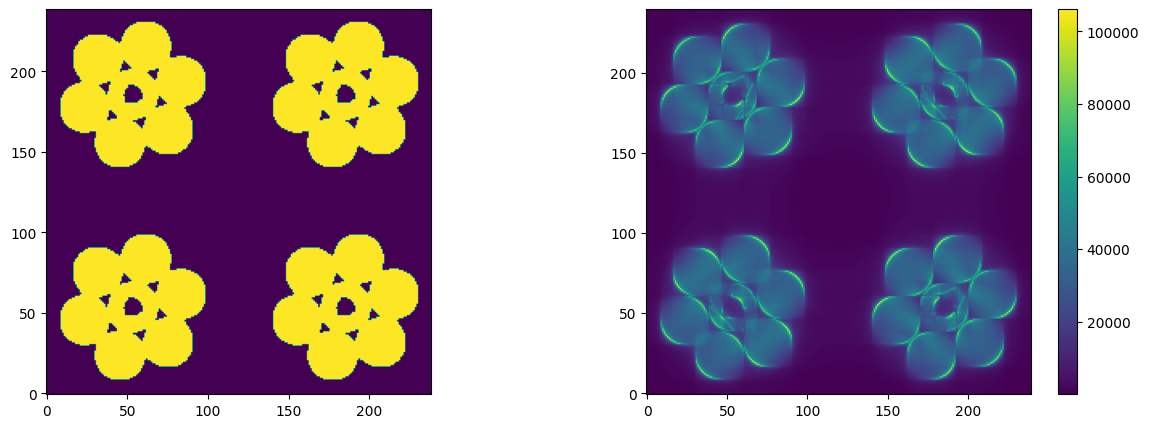

In [7]:
pyr_validpix = np.sum(pwfs.indpup, axis=0, dtype='bool')
extr = pwfs._extr
#xvalidpix, yvalidpix = np.where(pyr_validpix)
#pyr_validSAidx = wfs.get_subpupil(0, this_frame=wfs.indpup[0])

fig, (ax1,ax2) = plt.subplots(ncols=2)
fig.set_size_inches(15,5)
imm1 = ax1.imshow(pyr_validpix[extr:-1-extr, extr:-1-extr], origin='lower')
imm2 = ax2.imshow(pwfs.ccd_frame, origin='lower')
fig.colorbar(imm2, ax=ax2);

Show reference slope vector

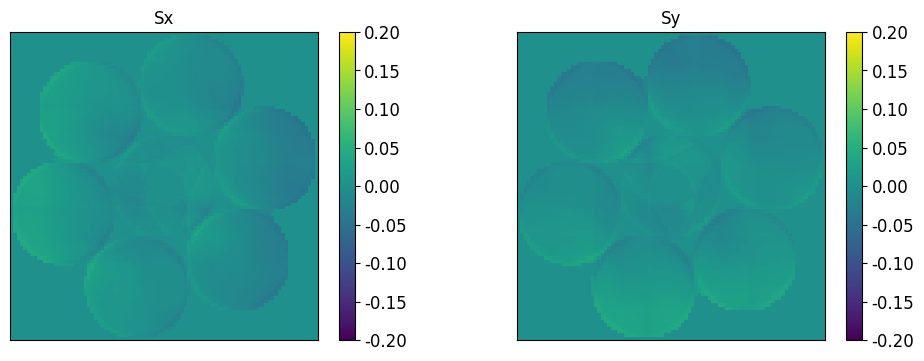

In [8]:
(sx_ref_2d,sy_ref_2d) = visu.pyr_display_signals(pwfs,
                                *pwfs.get_ref_measurement(out_format='list'))

### Check WFS photometry and noise statistics

In [9]:
pwfs.wfs.simul_noise = True

The noise parameters are stored in the `readout_params` dictionary, and be be modified after instantiation if needed:

In [10]:
print(pwfs.readout_params)

{'RON': 0.5, 'emccd_gain': 600, 'ADU_gain': 0.03333333333333333, 'emccd_nbits': 14}


You can also change the star magnitude after instantiation if needed:

Star mag: 10
Number of  expected GS photons per frame: 226748.2
Number of simulated GS photons per frame: 221367.8
Number of GS photons per SA per frame: 41.2
Number of GS photons per pixel per frame: 10.3


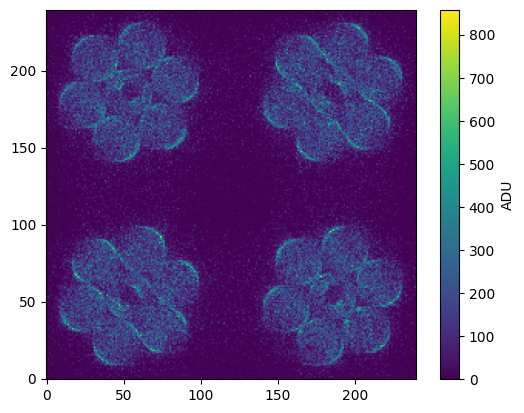

In [11]:
pwfs.reset() # resets the camera
meas = pwfs.measure(np.zeros((nPx,nPx)))
fr0 = pwfs.ccd_frame

nph_frame = np.sum(fr0)/(pwfs.readout_params['emccd_gain']*pwfs.readout_params['ADU_gain'])
nphsspp = nph_frame/pwfs.n_sspp # rough estimate of number of photons per SA per frame

print('Star mag: %d'%pwfs._pwfs_model__gs.magnitude)
print('Number of  expected GS photons per frame: %.1f'%(pwfs._pwfs_model__gs.nPhoton*PupilArea*pwfs.camera.photoelectron_gain*pyr_exposureTime))
print('Number of simulated GS photons per frame: %.1f'%(nph_frame))
print("Number of GS photons per SA per frame: %.1f"%(nphsspp))
print("Number of GS photons per pixel per frame: %.1f"%(nphsspp/4))

plt.imshow(fr0, origin='lower', interpolation=None)
clb=plt.colorbar(label='ADU');

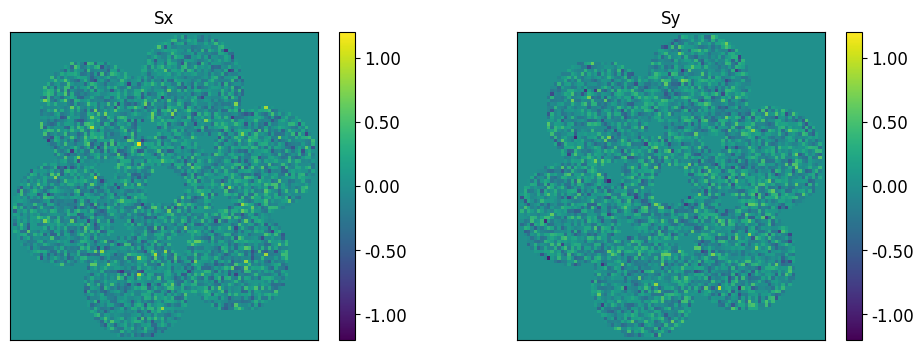

In [12]:
visu.pyr_display_signals(pwfs, meas[0:pwfs.n_sspp], meas[pwfs.n_sspp:]);

## Initialize Holographic DFS

In [13]:
#--- Spatial filter parameters
sps_fs_shape = 'round'
sps_fs_dim_mas = 50

sps_exposureTime = 150e-3
sps_RON = 0.5
sps_emccd_gain = 100
sps_ADU_gain = 1/2.76
sps_darkCurrent = 0.

In [14]:
hdfs = hdfs_model(array_size_pix=nPx, array_size_m=D, array_rot_angle=pup_angle, mag=mag, 
                  sps_fs_shape=sps_fs_shape, sps_fs_dim_mas=sps_fs_dim_mas,
                  T_out=sps_exposureTime, sps_RON = sps_RON, sps_emccd_gain = sps_emccd_gain, 
                  sps_ADU_gain = sps_ADU_gain, sps_darkCurrent = sps_darkCurrent)

---> Initializing HDFS...
Filename: /home/ubuntu/CEO/python/ceo/sensors/ngws_hdfs_phase_design_v2a_gaps.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  MASK          1 PrimaryHDU      12   (460, 460)   float64   
  1  PAIRS         1 ImageHDU         8   (2, 7)   int64   
  2  BASELINE      1 ImageHDU         7   (7,)   float64   
  3  ANGLE         1 ImageHDU         7   (7,)   float64   
  4  OFFSET        1 ImageHDU         7   (7,)   float64   


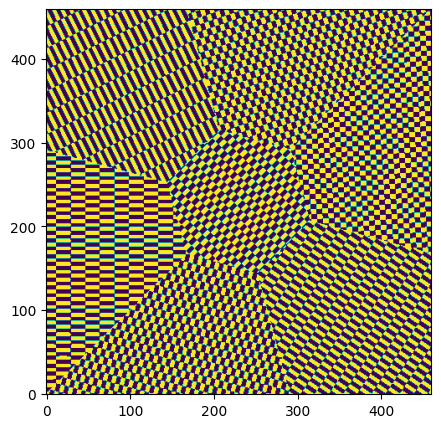

In [15]:
#--- Show the HDFS mask
fig, ax = plt.subplots()
fig.set_size_inches((5,5))
fig.dpi=100
ax.imshow(hdfs._HDFSmask.get(), origin='lower')

In [16]:
#------------------- Calibrate HDFS
hdfs.calibrate(project_truss_onaxis=project_truss_onaxis)

HDFS total flux should be equal to one, but we get: 0.4399


Show HDFS reference frame (noise-free)

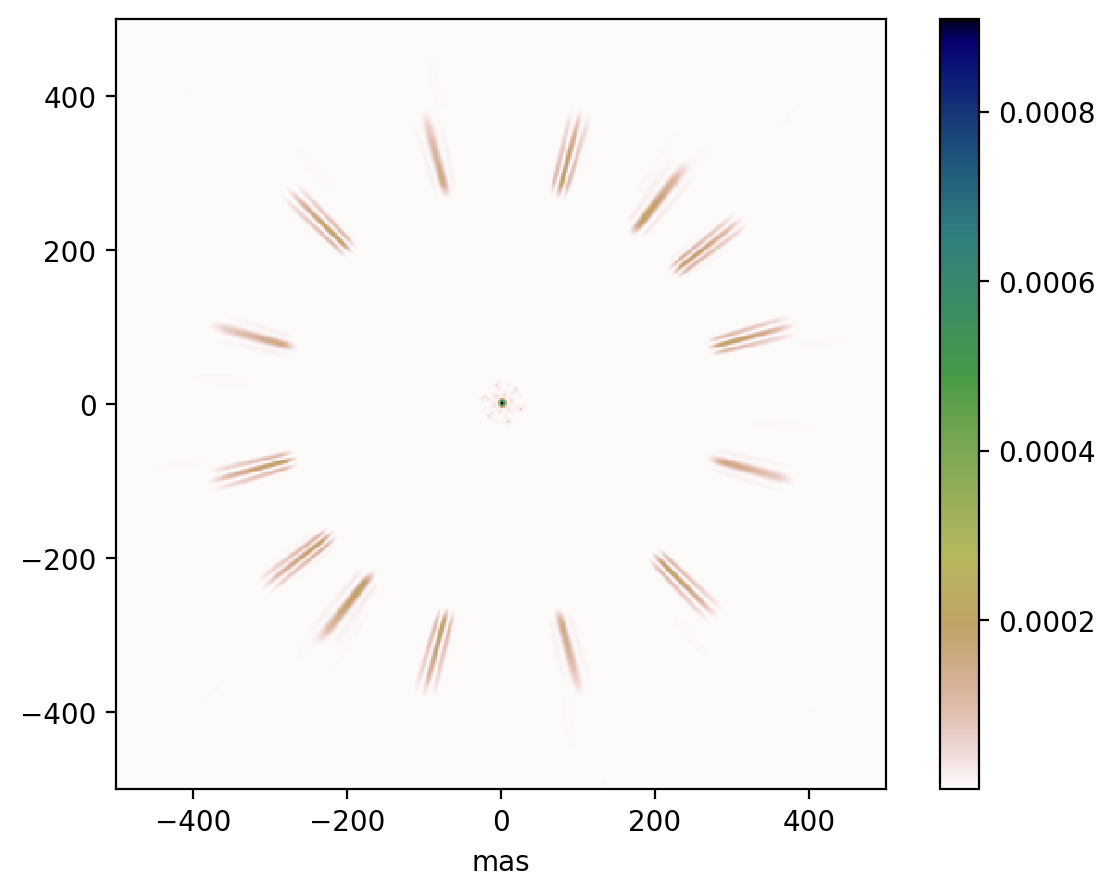

In [17]:
fig, ax1 = plt.subplots()
fig.set_size_inches((7,5))
fig.dpi = 200
imm1 = ax1.imshow(hdfs.ccd_frame, origin='lower', interpolation='None', cmap=plt.cm.gist_earth_r,
                  extent = hdfs._im_range_mas.tolist() * 2)
ax1.set_xlabel('mas')
clb1 = fig.colorbar(imm1, ax=ax1)

Show extracted fringes (noise-free)

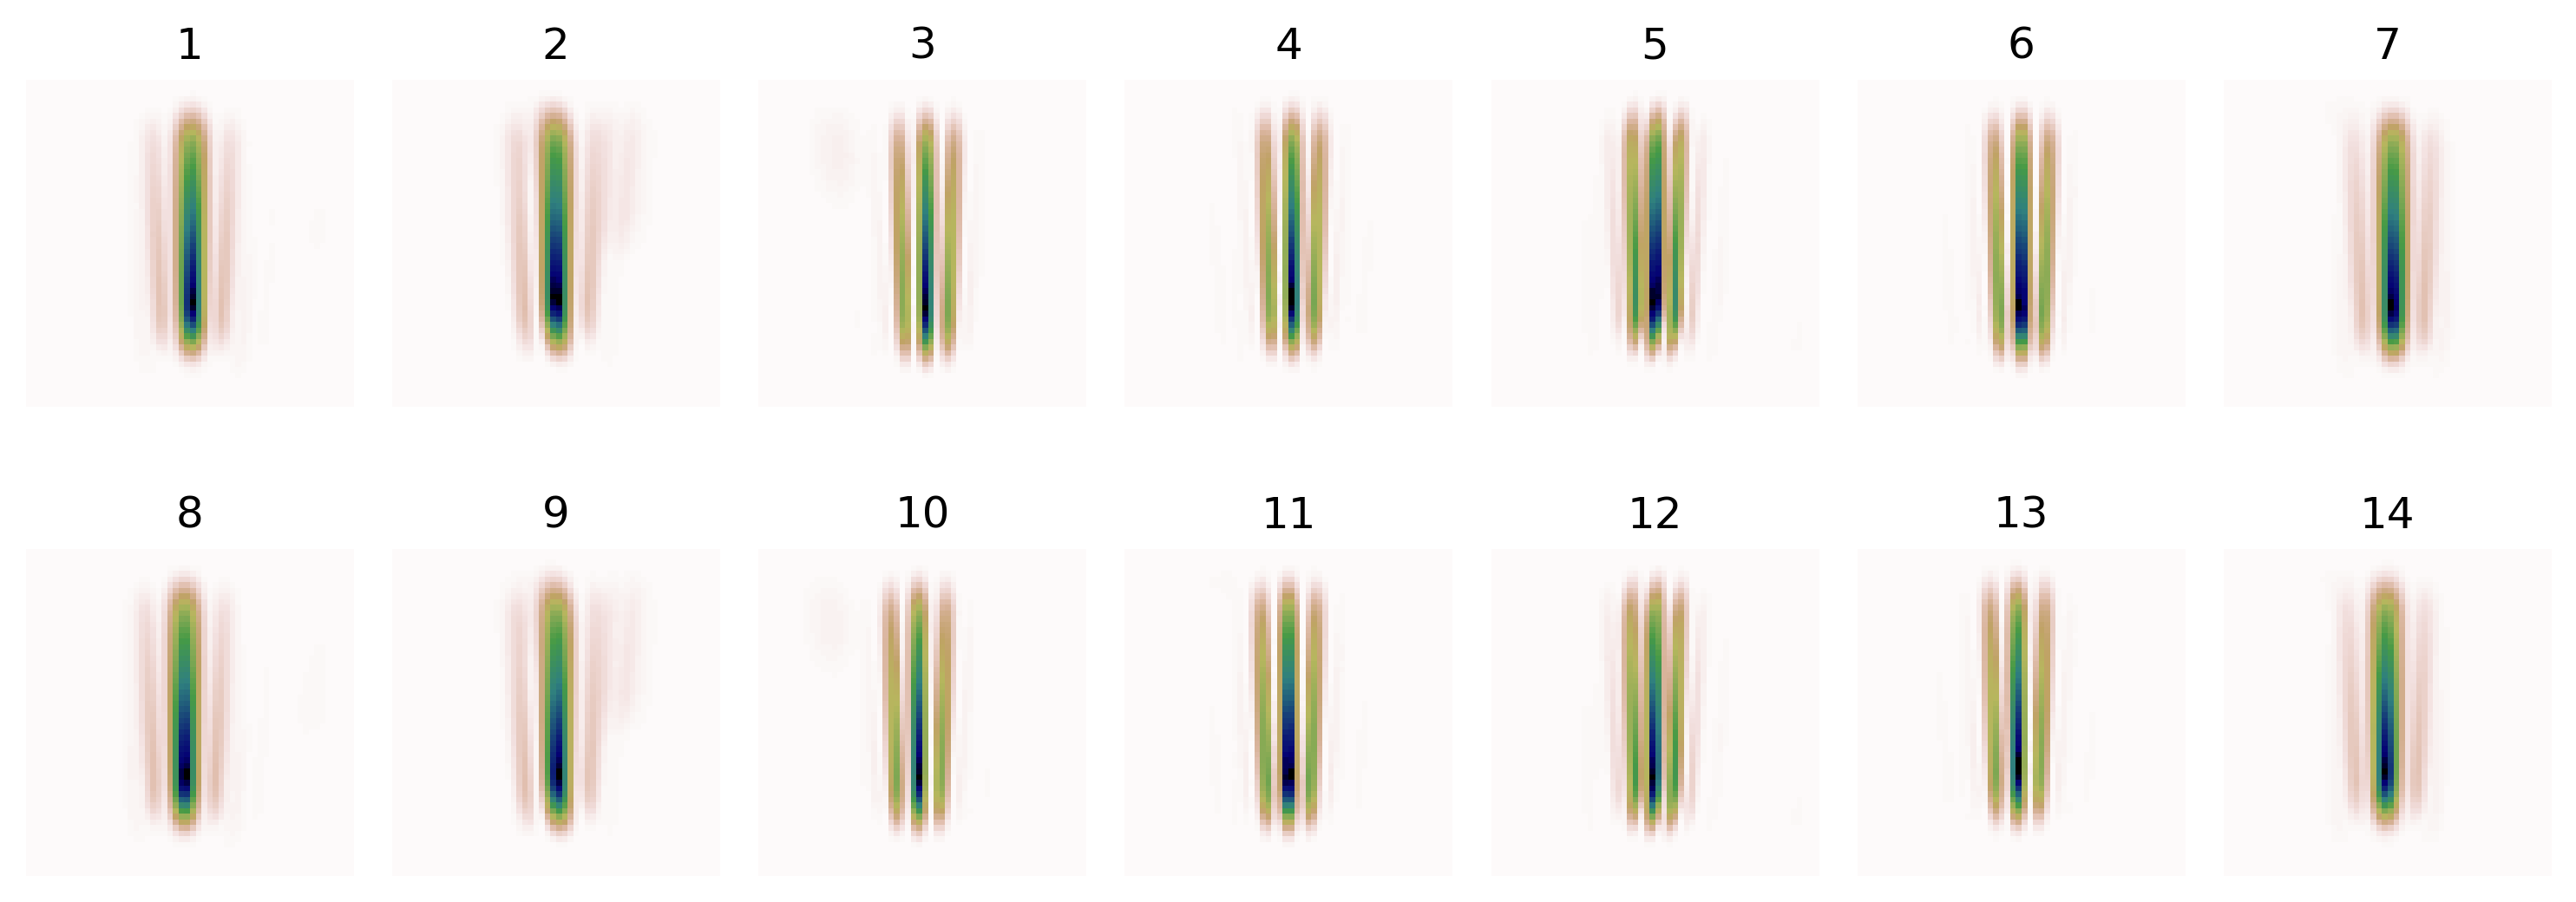

In [18]:
visu.hdfs_show_fringes(hdfs)

## Check HDFS photometry
(TO DO)

You can also change the star magnitude after instantiation if needed:

# Examples of NGWS-P signals
Load the GAPS telescope simulator model comprising the DM and PTT array and acquire some WFS measurements.

In [19]:
from telescope_simulator import telescope_simulator

In [20]:
#---> MEMS model parameters
ref_ifunc_fname = './data/mems2k/MagAO-X_MEMS2k_ReferenceIF.npz'
pupil_size_in_mems_pitches = 48
grid_rot_deg = -2.5

tel = telescope_simulator(nPx, ref_ifunc_fname, array_size_m = D, array_rot_angle = pup_angle, 
                    project_truss_onaxis = project_truss_onaxis, 
                    pupil_size_in_mems_pitches = pupil_size_in_mems_pitches,
                    mems_grid_rot_angle = grid_rot_deg)

--> Initializing GMT pupil.....
--> Initializing MEMS model.....
Completed creation of influence function cube of size 460 x 460 x 2040.
--> Initializing PTT array model.....
Done! .....


In [21]:
#--- Toggle WFS noise simulation
mag = 8
hdfs.mag = mag
pwfs.mag = mag

hdfs.wfs.simul_noise = True
pwfs.wfs.simul_noise = True

## DM poke signals

In [ ]:
this_act = 502
poke_amp = 500e-9
pwfs.reset()
IFfunc = (tel.mems2k.IFcube[:,:,this_act]*tel.pup.GMTmask2D) * poke_amp
slopes = pwfs.measure(IFfunc)

visu.pyr_display_signals(pwfs, slopes[0:pwfs.n_sspp], slopes[pwfs.n_sspp:]);

## Segment piston signals

### PWFS signals

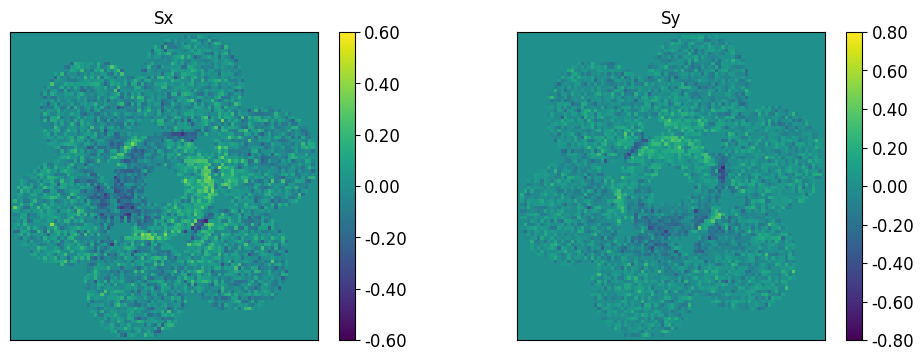

In [28]:
this_seg = 6  #from 0 to 6
poke_amp = 100e-9
pwfs.reset()
IFfunc = (tel.ptt.IFcube[:,:,this_seg*3]*tel.pup.GMTmask2D) * poke_amp
slopes = pwfs.measure(IFfunc)

visu.pyr_display_signals(pwfs, slopes[0:pwfs.n_sspp], slopes[pwfs.n_sspp:]);

### HDFS fringes

Maximum value is 68046.0, maximum allowed is 16383


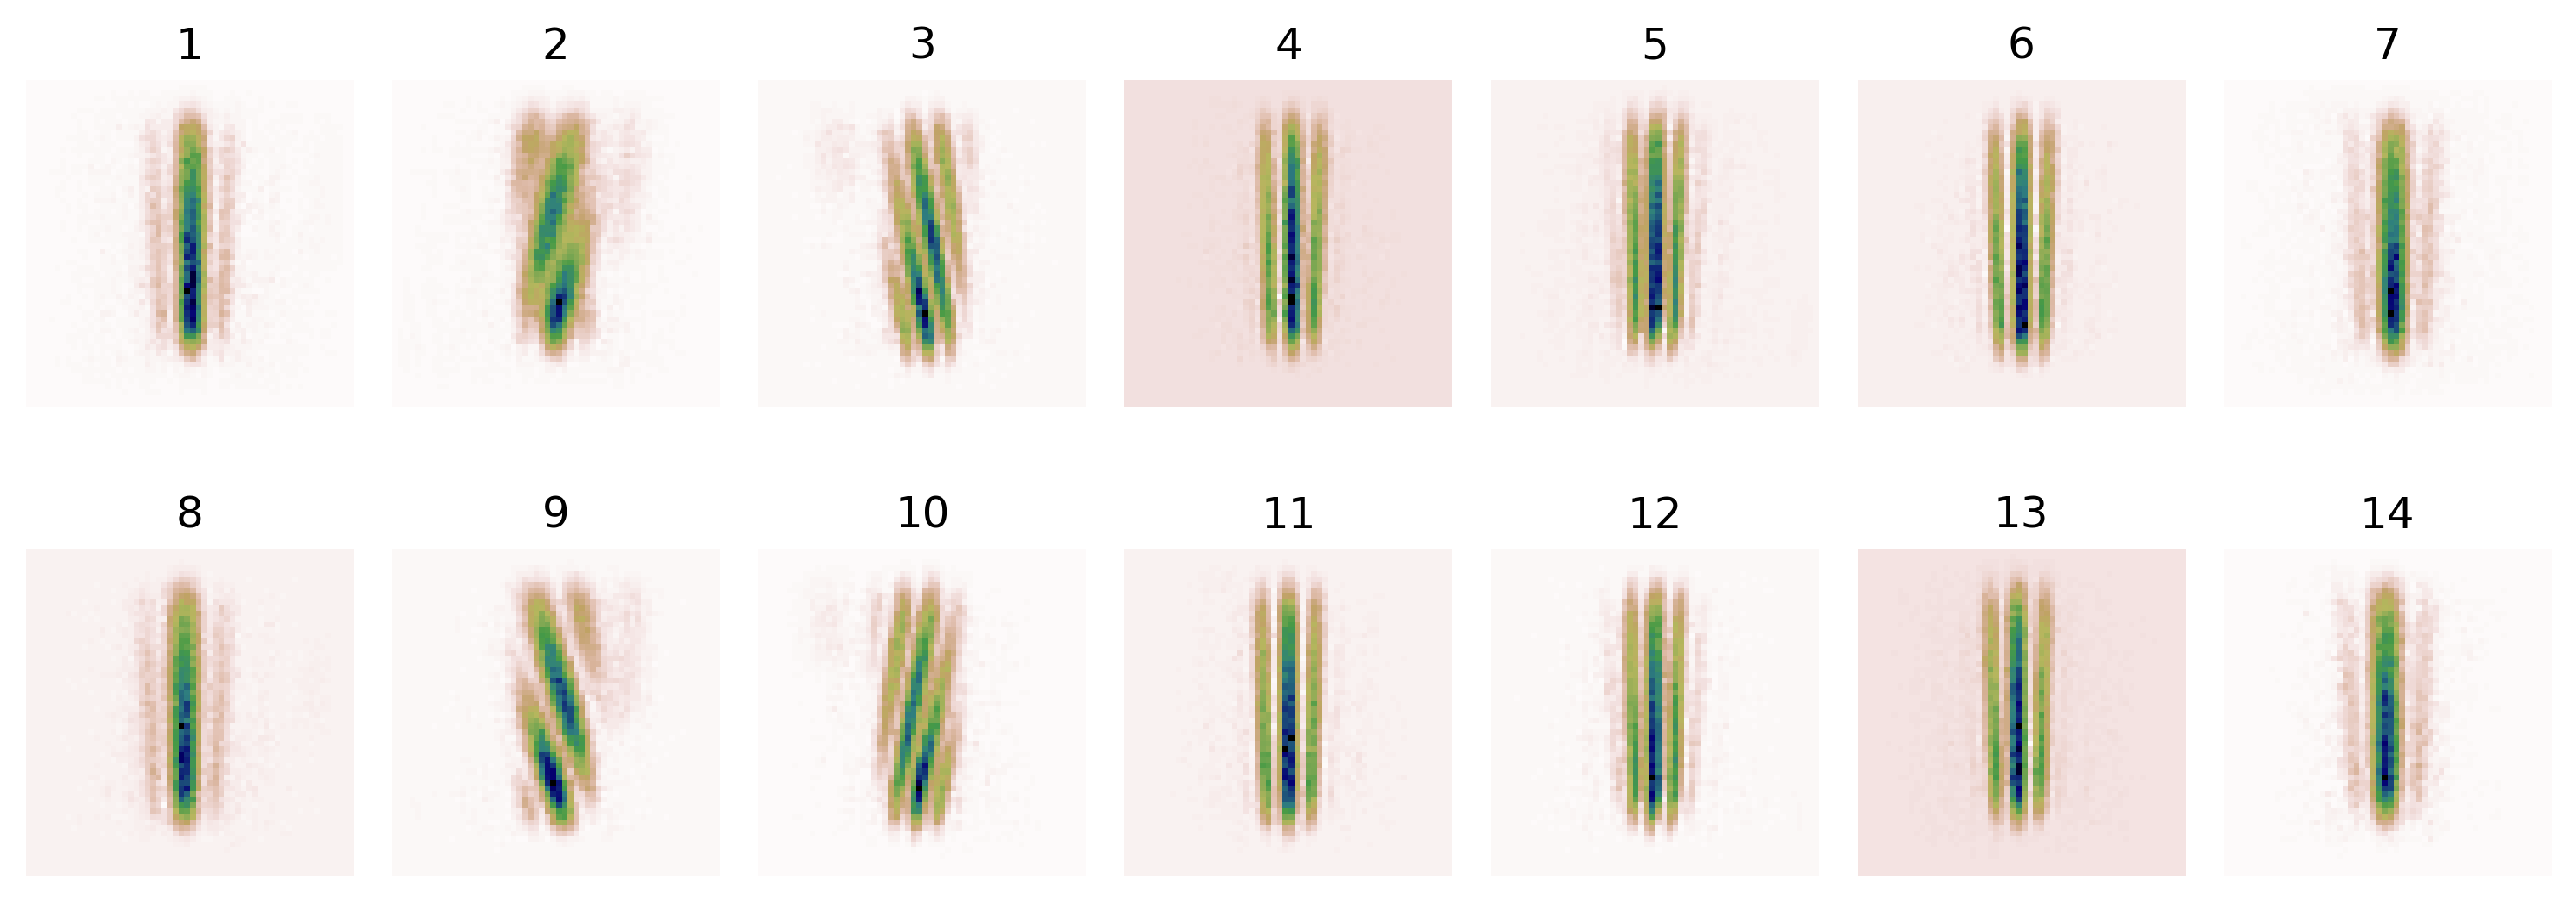

In [29]:
this_seg = 1  #from 0 to 6
poke_amp = 5e-6
hdfs.reset()
IFfunc = (tel.ptt.IFcube[:,:,this_seg*3]*tel.pup.GMTmask2D) * poke_amp
meas = hdfs.measure(IFfunc)

visu.hdfs_show_fringes(hdfs)

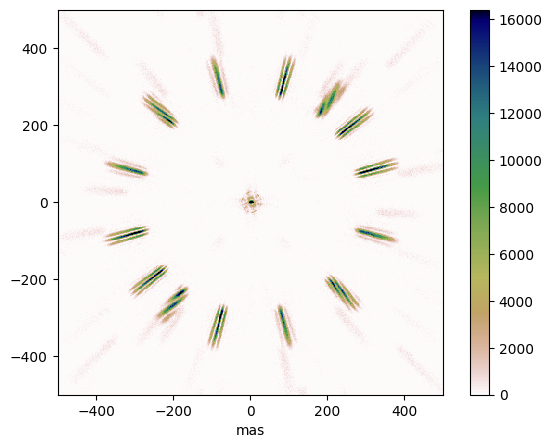

In [30]:
fig, ax1 = plt.subplots()
fig.set_size_inches((7,5))
fig.dpi = 100
imm1 = ax1.imshow(hdfs.ccd_frame, origin='lower', interpolation='None', cmap=plt.cm.gist_earth_r,
                  extent = hdfs._im_range_mas.tolist() * 2)
ax1.set_xlabel('mas')
clb1 = fig.colorbar(imm1, ax=ax1)